#### Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Состав таблицы, наличие пропусков

In [3]:
df = pd.read_csv('C:/Users/U_M1P8G/Desktop/IDE/Внедрение моделей ML/Сессионный проект/credit_card_ml_deployment/data/UCI_Credit_Card.csv')
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

Из данных выше видно, что:
1. Пропуски отсутствуют, что упрощает задачу
2. Все столбцы имеют числовой формат, т.е. нет необходимости в предварительном кодировании или подборе алгоритмов, имеющих нативную поддержку работы с категориальными признаками
3. Все представленные столбцы описаны на kaggle.

### 2. Анализ целевой переменной

In [8]:
target = 'default.payment.next.month'
df[target].value_counts(normalize = True)*100

default.payment.next.month
0    77.88
1    22.12
Name: proportion, dtype: float64

Видим умеренный дисбаланс. При разделении на тестовую и обучающую выборку будем использовать train_test_split(stratify=y) для того, чтобы в обучающей и тестовой выборках были одинаковые пропории целевой переменной.
Также при обучении будем применять class_weight='balanced'

### 3. Анализ аномалий

In [6]:
pd.set_option('display.max_columns', None)
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,-0.291100,51223.330900,49179.075167,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,1.149988,73635.860576,71173.768783,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,3558.750000,2984.750000,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,22381.500000,21200.000000,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67091.000000,64006.250000,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


Видим, что в колонках Education, Marriage и Pay_0 есть значения, отсутствующие в описании на Kaggle:
- Education - значение "6"
- Marriage - значение "0"
- Pay_* - Значение "-2"

Посмотрим на кол-во таких значений

In [11]:
# Количество значений
print("Eductaion value_counts:")
print(df['EDUCATION'].value_counts().sort_index())

print("\nMarriage value_counts:")
print(df['MARRIAGE'].value_counts().sort_index())

pay_cols = [col for col in df.columns if col.startswith('PAY_') and col != 'PAY_AMT']
any_minus2 = df[pay_cols].eq(-2).any(axis=1)
print(f"Клиенты хотя бы с одним PAY_* = -2: {any_minus2.sum()} ({(any_minus2.sum()/len(df)*100):.1f}%)")


Eductaion value_counts:
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

Marriage value_counts:
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64
Клиенты хотя бы с одним PAY_* = -2: 6561 (21.9%)


Клиентов с "-2" в хотя бы одном из столбцов Pay_* достаточно много (пости 22%).
Посмотрим, есть ли связь у этого значения с таргетом

In [12]:
# Сравнение дефолтов: клиенты с -2 vs без -2
print(f"\nДоля дефолтов:")
print(f"  Клиенты с PAY_0 = -2: {df.loc[df['PAY_0'] == -2, target].mean():.2%}")
print(f"  Клиенты с PAY_0 != -2: {df.loc[df['PAY_0'] != -2, target].mean():.2%}")
print(f"  Все клиенты: {df[target].mean():.2%}")


Доля дефолтов:
  Клиенты с PAY_0 = -2: 13.23%
  Клиенты с PAY_0 != -2: 23.02%
  Все клиенты: 22.12%


#### Выводы по аномалиям данных

1. EDUCATION - обнаружены недокументированные значения

 **Решение**: в связи с малой численностью категорий объединить значения 0, 5, 6 с категорией 4 (others). Итоговый размер категории "others": 468 записей (1.56%).

2. MARRIAGE - обнаружены недокументированные значения

**Решение**: в связи с малой численностью категории объединить с категорией 3 (others). Итоговый размер категории "others": 377 записей (1.26%).

3. PAY_* значения -2 - позитивный сигнал, не аномалия
- Встречается у 21.9% клиентов
- клиенты с PAY_0 = -2 имеют меньший риск дефолта
**Решение**: оставить -2 как отдельную категорию. Потенциально создать бинарный признак HAS_MINUS2

4. Отрицательные BILL_AMT — бизнес-логика
- Отрицательные значения означают переплату или кредитный баланс в пользу клиента
- Являются нормальным поведением, не ошибкой данных
- **Решение**: оставить без изменений

5. Нулевые PAY_AMT при положительных BILL_AMT
- Отражают отсутствие платежа по счёту
- Потенциально важный предиктор дефолта
- **Решение**: оставить как значимый признак

#### **Итоговые действия по очистке данных**:
1. EDUCATION: 0, 5, 6 объединить с 4
2. MARRIAGE: 0 объединить с 3
3. PAY_* (-2): оставлен как отдельная категория
4. Остальные признаки оставлены без изменений

### 4. Анализ распределений

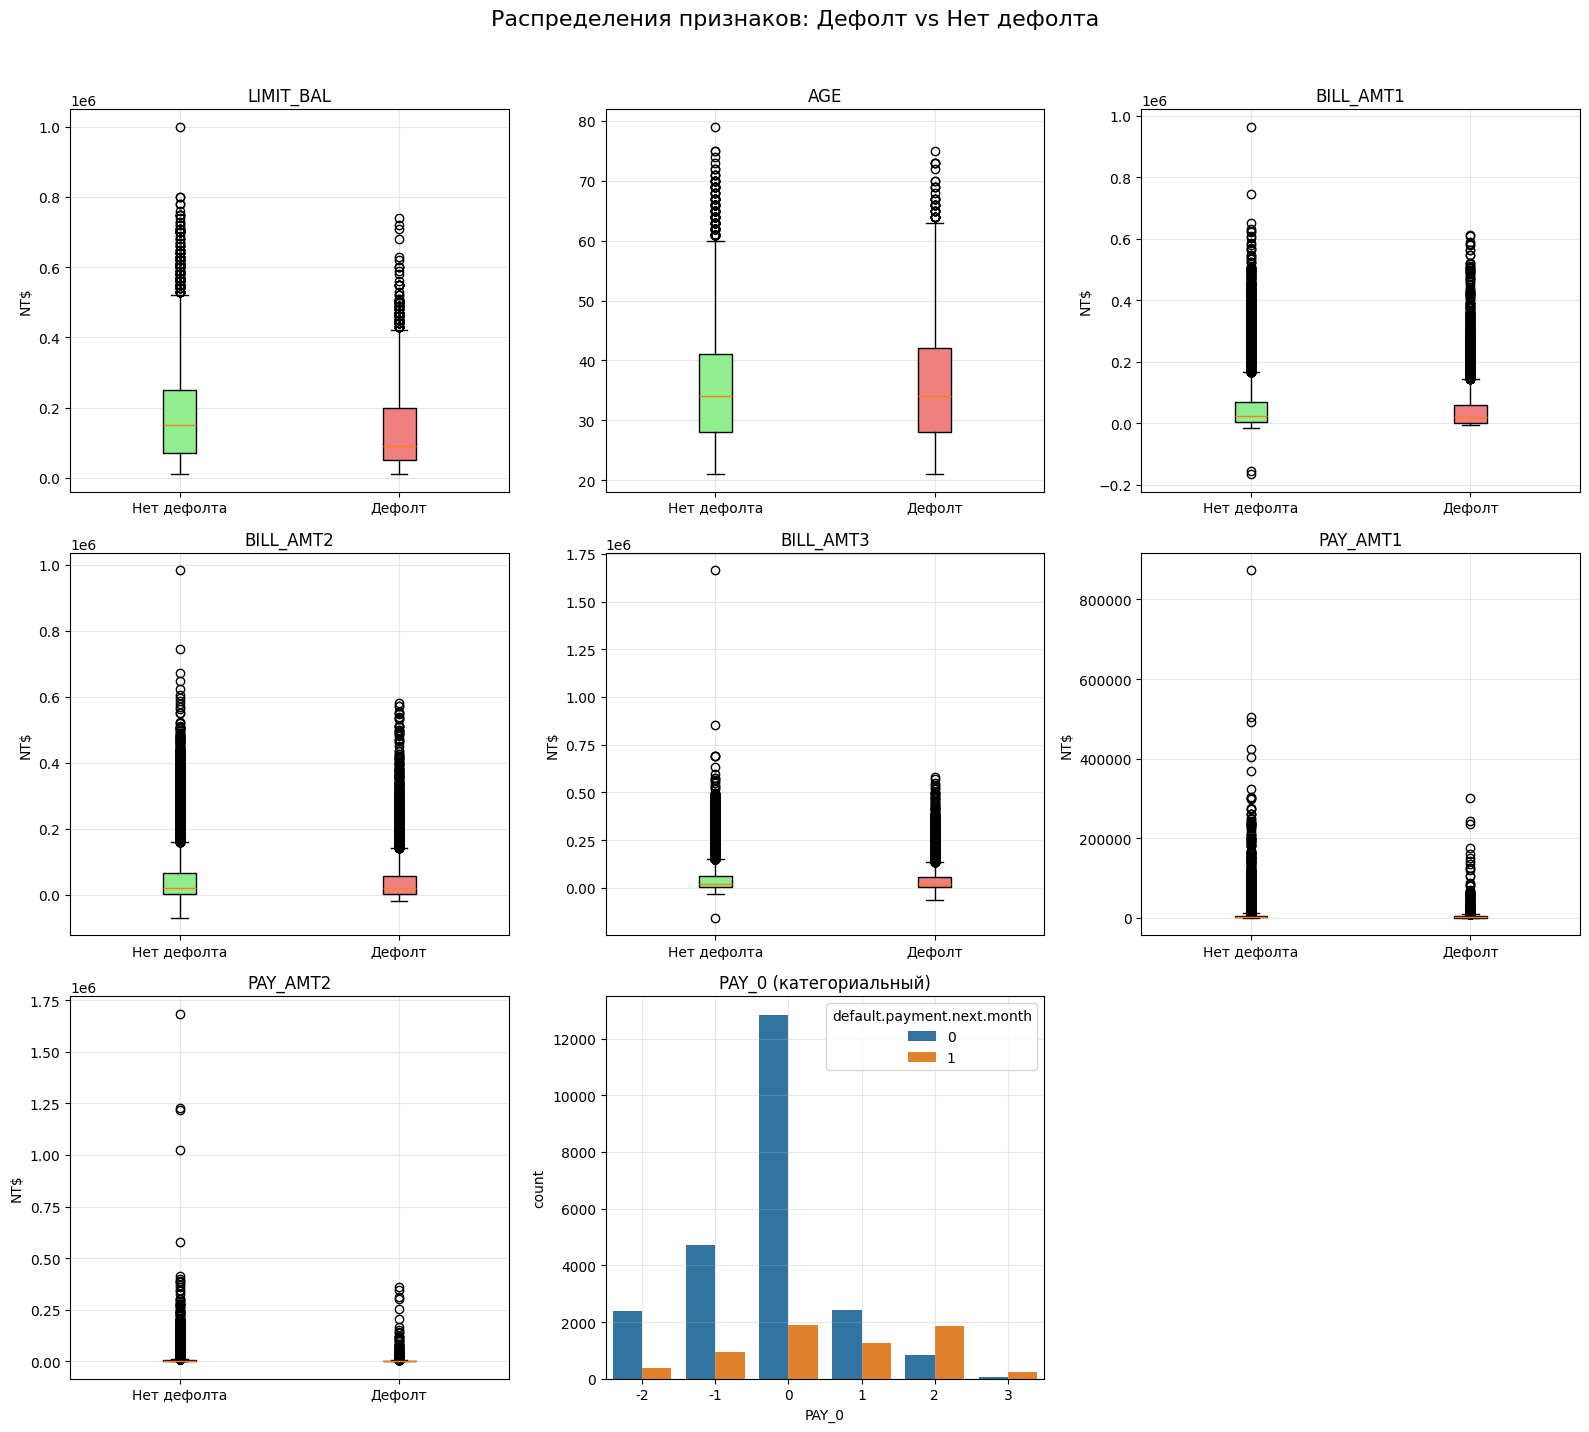

      Признак        Q1         Q3        IQR  Нижняя граница  Верхняя граница  Кол-во выбросов  % выбросов       Min        Max
0   LIMIT_BAL  50000.00  240000.00  190000.00     -235000.000       525000.000              167    0.556667   10000.0  1000000.0
1         AGE     28.00      41.00      13.00           8.500           60.500              272    0.906667      21.0       79.0
2   BILL_AMT1   3558.75   67091.00   63532.25      -91739.625       162389.375             2400    8.000000 -165580.0   964511.0
3   BILL_AMT2   2984.75   64006.25   61021.50      -88547.500       155538.500             2395    7.983333  -69777.0   983931.0
4   BILL_AMT3   2666.25   60164.75   57498.50      -83581.500       146412.500             2469    8.230000 -157264.0  1664089.0
5   BILL_AMT4   2326.75   54506.00   52179.25      -75942.125       132774.875             2622    8.740000 -170000.0   891586.0
6   BILL_AMT5   1763.00   50190.50   48427.50      -70878.250       122831.750             2725  

In [14]:
# Разделим клиентов на дефолтных и нет
df_default = df[df[target] == 1]
df_no_default = df[df[target] == 0]

# Создадим фигуру с подграфиками
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

# Признаки для анализа
features = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
            'PAY_AMT1', 'PAY_AMT2', 'PAY_0', 'default.payment.next.month'] # Возьмем только Pay_0 как потенциально более сильный предиктор

for i, feature in enumerate(features):
    if feature == 'default.payment.next.month':
        continue
    
    ax = axes[i]
    
    if feature in ['PAY_0']:
        # Для категориальных - countplot с разделением по дефолту
        pay_data = df[df[feature].isin([-2, -1, 0, 1, 2, 3])]
        sns.countplot(x=feature, hue=target, data=pay_data, ax=ax)
        ax.set_title(f'{feature} (категориальный)')
    else:
        # Для числовых - boxplot с разделением
        data_to_plot = [df_no_default[feature].dropna(), df_default[feature].dropna()]
        bp = ax.boxplot(data_to_plot, tick_labels=['Нет дефолта', 'Дефолт'], patch_artist=True)
        bp['boxes'][0].set_facecolor('lightgreen')
        bp['boxes'][1].set_facecolor('lightcoral')
        ax.set_title(f'{feature}')
        ax.set_ylabel('NT$' if 'AMT' in feature or 'BAL' in feature else '')
    
    ax.grid(True, alpha=0.3)

# Убираем пустые подграфики
for j in range(len(features)-1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Распределения признаков: Дефолт vs Нет дефолта', fontsize=16, y=1.02)
plt.tight_layout()
# сохраним графики
plt.savefig('C:/Users/U_M1P8G/Desktop/IDE/Внедрение моделей ML/Сессионный проект/credit_card_ml_deployment/data/processed/distributions.png', dpi=150, bbox_inches='tight')
plt.show()


# Поиск выбросов методом IQR

numeric_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
                'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 
                'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

outliers_report = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    pct_outliers = len(outliers) / len(df) * 100
    
    outliers_report.append({
        'Признак': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Нижняя граница': lower_bound,
        'Верхняя граница': upper_bound,
        'Кол-во выбросов': len(outliers),
        '% выбросов': pct_outliers,
        'Min': df[col].min(),
        'Max': df[col].max()
    })

report_df = pd.DataFrame(outliers_report)
print(report_df.to_string())

# Сравнение медиан: ДЕФОЛТ vs НЕТ дефолта

comparison = pd.DataFrame({
    'Признак': numeric_cols,
    'Медиана (Нет дефолта)': [df_no_default[col].median() for col in numeric_cols],
    'Медиана (Дефолт)': [df_default[col].median() for col in numeric_cols],
    'Разница (%)': [((df_default[col].median() - df_no_default[col].median()) / 
                      df_no_default[col].median() * 100) if df_no_default[col].median() != 0 else 0 
                    for col in numeric_cols]
})
print(comparison.to_string())

#### Выводы:

1. Выбросы (IQR-метод)
- AGE: 0.9% (272 чел, возраст 61-79) - это не аномалия, а реальные клиенты в возрасте, не удаляем
- LIMIT_BAL: 0.6% (167 чел, лимиты >525к) - скорре всего, это VIP-клиенты, не удаляем
- BILL_AMT/PAY_AMT: 8-10% - клиенты с экстремальными суммами, важны для модели
 **Решение**: выбросы не удаляем, используем StandardScaler, который компенсирует разброс

2. Ключевые различия дефолт/не дефолт
- Снижение платежей (PAY_AMT) за 3-6 месяцев до дефолта на 40-43% - сильнейший предиктор
- Лимит кредита у дефолтников на 40% ниже
- Суммы счетов (BILL_AMT) различаются слабо
- Возраст не различается - не является предиктором

3. Идеи для новых признаков
- PAY_AMT_TREND = PAY_AMT1 / PAY_AMT4 - тренд изменения платежей
- CREDIT_UTILIZATION = BILL_AMT1 / LIMIT_BAL - использование лимита

### 5. Feature Engineering

#### 5.1 Создание новых признаков

In [16]:
df_fe = df.copy()

# PAY_* признаки
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
df_fe['PAY_MEAN'] = df[pay_cols].mean(axis=1)
df_fe['PAY_MAX'] = df[pay_cols].max(axis=1)
df_fe['PAY_TREND'] = df['PAY_0'] - df['PAY_6']
df_fe['PAY_DELAY_COUNT'] = (df[pay_cols] > 0).sum(axis=1)
df_fe['HAS_MINUS2'] = (df[pay_cols] == -2).any(axis=1).astype(int)

# BILL_* признаки
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
df_fe['BILL_MEAN'] = df[bill_cols].mean(axis=1)
df_fe['BILL_TREND'] = df['BILL_AMT1'] - df['BILL_AMT6']

# PAY_AMT признаки
pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
df_fe['PAY_AMT_MEAN'] = df[pay_amt_cols].mean(axis=1)
df_fe['PAY_AMT_TREND'] = df['PAY_AMT1'] / (df[['PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']].mean(axis=1) + 1)

# Использование лимита
df_fe['CREDIT_USAGE'] = df['BILL_AMT1'] / (df['LIMIT_BAL'] + 1)

#### 5.2 Корреляционный анализ всех признаков

In [18]:
# Исключаем ID
if 'ID' in df_fe.columns:
    df_fe = df_fe.drop('ID', axis=1)

# Корреляция с таргетом
target_corr = df_fe.corr()[target].drop(target).sort_values(key=abs, ascending=False)

# Выведем топ-20 признаков по корреляции:
print("Топ-20 признаков по корреляции")

top_features = target_corr.head(20)
for i, (feature, corr) in enumerate(top_features.items(), 1):
    print(f"{i:2}. {feature:<25} {corr:+.4f}")

# Проверим мультиколлинеарность

print("\nПроверка мультиколлинеарности:\n")

# Матрица корреляций
corr_matrix = df_fe.corr().abs()

# Находим пары с корреляцией > 0.85
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.85:
            high_corr.append({
                'Признак 1': corr_matrix.columns[i],
                'Признак 2': corr_matrix.columns[j],
                'Корреляция': corr_matrix.iloc[i, j]
            })

if high_corr:
    high_corr_df = pd.DataFrame(high_corr).sort_values('Корреляция', ascending=False)
    print(high_corr_df.to_string())
else:
    print("Сильной мультиколлинеарности нет")

Топ-20 признаков по корреляции
 1. PAY_DELAY_COUNT           +0.3984
 2. PAY_MAX                   +0.3310
 3. PAY_0                     +0.3248
 4. PAY_MEAN                  +0.2820
 5. PAY_2                     +0.2636
 6. PAY_3                     +0.2353
 7. PAY_4                     +0.2166
 8. PAY_5                     +0.2041
 9. PAY_6                     +0.1869
10. LIMIT_BAL                 -0.1535
11. PAY_TREND                 +0.1288
12. PAY_AMT_MEAN              -0.1024
13. CREDIT_USAGE              +0.0862
14. PAY_AMT1                  -0.0729
15. PAY_AMT2                  -0.0586
16. PAY_AMT4                  -0.0568
17. PAY_AMT3                  -0.0563
18. PAY_AMT5                  -0.0551
19. PAY_AMT6                  -0.0532
20. SEX                       -0.0400

Проверка мультиколлинеарности:

    Признак 1  Признак 2  Корреляция
18  BILL_AMT4  BILL_MEAN    0.964501
15  BILL_AMT3  BILL_MEAN    0.961958
11  BILL_AMT2  BILL_MEAN    0.961178
20  BILL_AMT5  BILL_MEAN    

#### Корреляционный анализ признаков

1. История платежей (PAY_*) доминирует:
   - Все 6 PAY_ признаков входят в ТОП-8
   - Сила убывает с давностью, т.е. свежий статус важнее старых

2. Новые признаки эффективнее исходных
   - PAY_DELAY_COUNT (0.398) - сильнее любого исходного признака
   - PAY_MAX` (0.331) - на уровне PAY_0
   - Агрегации работают лучше отдельных месяцев

3. LIMIT_BAL - единственный сильный не-PAY признак: отрицательная корреляция: чем ниже лимит, тем выше риск дефолта

4. Суммы счетов (BILL_AMT) слабо предсказывают дефолт, а также имеют проблему сильной мультиколлинеарности между собой (>0.85)

5. Демографические признаки почти бесполезны

**Финальный набор признаков для модели**
 Оставляем 13 признаков:

*Исходные (7):*
- LIMIT_BAL, PAY_0, PAY_2, PAY_3, PAY_4, PAY_5, PAY_6

*Новые (6):*
- PAY_DELAY_COUNT - количество месяцев с просрочкой
- PAY_MAX - максимальная задержка
- PAY_TREND - ухудшение статуса (PAY_0 - PAY_6)
- PAY_AMT_MEAN - средний платёж за полгода
- CREDIT_USAGE - использование кредитного лимита
- BILL_AMT1 - свежий счёт (оставляем один вместо 6)